In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [25]:
# load precipitation data
ds_prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
ds_prec = ds_prec.sel(time = slice('1979', '2019')) 
ds_prec.load()

# load SST data
ds_sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [26]:
# calculate nino34
#make anomaly
sst_clim = ds_sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst.sst.groupby('time.month') - sst_clim

In [27]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [28]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
nino34 = oni34.sel(time=slice('1979', '2019'))  

In [29]:
ds_sst = ds_sst.sel(time=slice('1979', '2019'))  

In [30]:
ds_climo = ds_prec.groupby('time.month').mean()
ds_anoms = ds_prec.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 -0.02191 -0.03154 ... -0.2816 -0.2292

In [31]:
#scipy
from scipy.stats import linregress

In [32]:
nx = len(ds_anoms['lon'])
ny = len(ds_anoms['lat'])

p_array = np.zeros((ny,nx))
r_array = np.zeros((ny,nx))
m_array = np.zeros((ny,nx))

for i in range(nx):
    for j in range(ny):
        
        x=nino34
        y=ds_anoms['precip'][:,j,i]
        
        m,b,r,p,e = linregress(x,y)
        
        m_array[j,i]=m
        r_array[j,i]=r
        p_array[j,i]=p

In [33]:
#mask
mask_sig=np.where(p_array<0.05,m_array,np.nan)

Text(0.5, 1.0, 'Regression between Nino3.4 and Precipitation Anomalies')

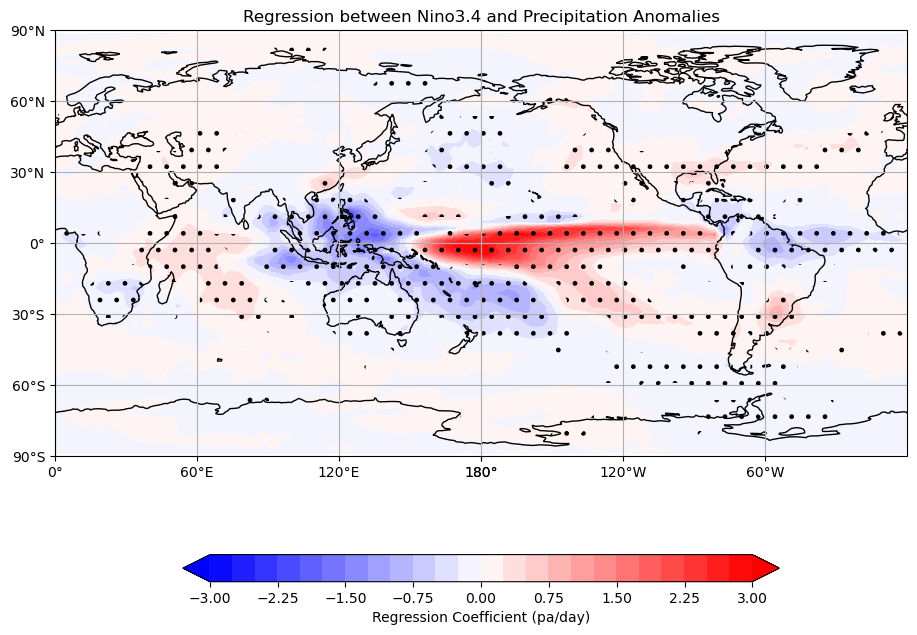

In [34]:
#plotting
clevs=np.arange(-3,3.25,0.25)

fig = plt.figure(figsize=(11,8.5))

# Set the axes using the specified map projection
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Add cyclic point
data = m_array
data,lon=add_cyclic_point(data,coord=ds_anoms['lon'])
mask_data,lons=add_cyclic_point(mask_sig,coord=ds_anoms['lon'])

# Make a filled contour plot
cs=ax.contourf(lon,ds_anoms['lat'],
            data,clevs,
            transform=ccrs.PlateCarree(),
            cmap='bwr',extend='both')

ax.contourf(lon,ds_anoms['lat'],mask_data,[0,1],
            transform = ccrs.PlateCarree(),colors='None',
            hatches=['.','.'],extend='both',alpha=0)

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs=ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs=ccrs.PlateCarree())
lat_formatter=cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar=plt.colorbar(cs,orientation='horizontal',shrink=0.7,
                 label='Regression Coefficient (pa/day)')

# Add title
plt.title('Regression between Nino3.4 and Precipitation Anomalies')

In [35]:
ds_mslp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\mslp.mon.mean.nc")
ds_mslp = ds_mslp.sel(time = slice('1979', '2019')) 
ds_mslp.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 492, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 1.008e+05
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [36]:
#make anomaly
mslp_clim = ds_mslp.mslp.groupby('time.month').mean(dim = 'time')
mslp_anom = ds_mslp.mslp.groupby('time.month') - mslp_clim

In [37]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
mslp_anom_detrended = xr.apply_ufunc(detrend, mslp_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~mslp_anom.isnull())

In [38]:
#select month 
mslp_anom_detrended = mslp_anom_detrended.sel(time = ds_mslp.time.dt.month.isin([1, 2, 12]))
mslp_anom_detrended

<xarray.DataArray 'mslp' (time: 123, lat: 73, lon: 144)>
array([[[  868.9231   ,   868.9231   ,   868.9231   , ...,
           868.9231   ,   868.9231   ,   868.9231   ],
        [  931.12427  ,   929.4864   ,   927.64056  , ...,
           937.2744   ,   935.8276   ,   933.15875  ],
        [  944.2737   ,   943.6587   ,   941.0119   , ...,
           948.5652   ,   947.6815   ,   945.9608   ],
        ...,
        [ -328.35245  ,  -319.0705   ,  -309.22632  , ...,
          -357.62933  ,  -347.35553  ,  -338.66803  ],
        [ -404.15182  ,  -401.47247  ,  -399.89667  , ...,
          -413.5592   ,  -410.5562   ,  -407.17047  ],
        [ -412.07788  ,  -412.07788  ,  -412.07788  , ...,
          -412.07788  ,  -412.07788  ,  -412.07788  ]],

       [[  291.85806  ,   291.85806  ,   291.85806  , ...,
           291.85806  ,   291.85806  ,   291.85806  ],
        [  367.97742  ,   370.10074  ,   370.71954  , ...,
           363.48672  ,   364.75302  ,   366.49335  ],
        [  457.68848  ,   463.55032  ,   468.2487   , ...,
           439.2609   ,   445.96695  ,   451.78275  ],
...
        [ -493.7439   ,  -518.4218   ,  -539.4324   , ...,
          -398.43     ,  -432.42303  ,  -463.8316   ],
        [ -533.7085   ,  -546.2803   ,  -557.18317  , ...,
          -489.71234  ,  -505.34592  ,  -519.95264  ],
        [  -89.0285   ,   -89.0285   ,   -89.0285   , ...,
           -89.0285   ,   -89.0285   ,   -89.0285   ]],

       [[  301.568    ,   301.568    ,   301.568    , ...,
           301.568    ,   301.568    ,   301.568    ],
        [  248.26672  ,   259.07538  ,   268.77365  , ...,
           220.21194  ,   229.65915  ,   239.01591  ],
        [  116.75097  ,   131.4582   ,   145.79388  , ...,
            71.70141  ,    86.80322  ,   101.8443   ],
        ...,
        [  462.9928   ,   445.80316  ,   428.78647  , ...,
           521.6772   ,   501.1363   ,   481.76123  ],
        [  390.2935   ,   383.17548  ,   377.45978  , ...,
           414.77734  ,   405.08984  ,   397.5884   ],
        [  797.0259   ,   797.0259   ,   797.0259   , ...,
           797.0259   ,   797.0259   ,   797.0259   ]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [39]:
nino34_cut = nino34.sel(time = nino34.time.dt.month.isin([1, 2, 12]))
nino34_cut

<xarray.DataArray 'sst' (time: 123)>
array([ 0.03640657,  0.06104225,  0.647905  ,  0.5921905 ,  0.43913525,
        0.05750963, -0.15359092, -0.3696098 ,  0.03186483,  0.08237441,
        0.20221737,  2.331637  ,  2.3047385 ,  2.0427823 , -0.8104355 ,
       -0.4788962 , -0.29906794, -1.0491431 , -0.92821074, -0.734226  ,
       -0.30744475, -0.44613618, -0.43667835,  1.2492932 ,  1.2592015 ,
        1.2246811 ,  1.1353838 ,  0.8384816 ,  0.5663761 , -1.8290737 ,
       -1.6690781 , -1.40747   , -0.03688875,  0.15331623,  0.22426546,
        0.4681602 ,  0.50588304,  0.4097857 ,  1.7074442 ,  1.8667129 ,
        1.7746489 ,  0.04514719,  0.24397771,  0.43374574,  0.22475187,
        0.20910177,  0.19936578,  1.2584484 ,  1.1009339 ,  0.84911597,
       -0.8358264 , -0.7876224 , -0.66588557, -0.4051709 , -0.42355224,
       -0.27999297,  2.4729962 ,  2.3140805 ,  2.008081  , -1.4924077 ,
       -1.4783318 , -1.2249216 , -1.5807875 , -1.599037  , -1.33844   ,
       -0.7042594 , -0.683442  , -0.52761656, -0.2066172 , -0.12988567,
        0.01826414,  1.238705  ,  0.93407416,  0.61002326,  0.44161373,
        0.37553403,  0.27980018,  0.7721945 ,  0.64090884,  0.55264634,
       -0.72655725, -0.78505325, -0.7041898 ,  1.0220568 ,  0.70373815,
        0.27583724, -1.5233023 , -1.5992785 , -1.4648871 , -0.6659182 ,
       -0.8084502 , -0.7436733 ,  1.6287696 ,  1.5303106 ,  1.2626469 ,
       -1.533118  , -1.3847125 , -1.1436427 , -0.97833604, -0.84217024,
       -0.6838139 , -0.15816745, -0.41064692, -0.39767337, -0.22421908,
       -0.41740376, -0.44737792,  0.6948664 ,  0.56040436,  0.495569  ,
        2.6784916 ,  2.4912815 ,  2.1565459 , -0.52505   , -0.3361355 ,
       -0.14841138, -0.94850534, -0.92040986, -0.84319437,  0.85121363,
        0.75853527,  0.74736613,  0.5847127 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 12 1 2 12 1 2 12 1 2 ... 2 12 1 2 12 1 2 12 1 2 12

In [40]:
nx = len(mslp_anom_detrended['lon'])
ny = len(mslp_anom_detrended['lat'])

p_array = np.zeros((ny,nx))
r_array = np.zeros((ny,nx))
m_array = np.zeros((ny,nx))

for i in range(nx):
    for j in range(ny):
        
        x = nino34_cut
        y = mslp_anom_detrended[:,j,i]
        
        m,b,r,p,e = linregress(x,y)
        
        m_array[j,i] = m
        r_array[j,i] = r
        p_array[j,i] = p

In [41]:
mask_sig = np.where(p_array<0.001,m_array,np.nan)

In [42]:
m_array

array([[50.31300522, 50.31300522, 50.31300522, ..., 50.31300522,
        50.31300522, 50.31300522],
       [44.11743154, 44.08645227, 44.04413148, ..., 44.32971696,
        44.22657628, 44.22894207],
       [32.6461584 , 32.32362599, 32.16481538, ..., 33.07185248,
        32.86582818, 32.72413444],
       ...,
       [38.19195387, 37.0014566 , 35.93338674, ..., 42.24628944,
        40.8453797 , 39.4377495 ],
       [26.65093741, 26.90677153, 27.15993384, ..., 26.40249333,
        26.40054114, 26.52017198],
       [45.89987279, 45.89987279, 45.89987279, ..., 45.89987279,
        45.89987279, 45.89987279]])

Text(1.0, 1.0, '99.9% sig.')

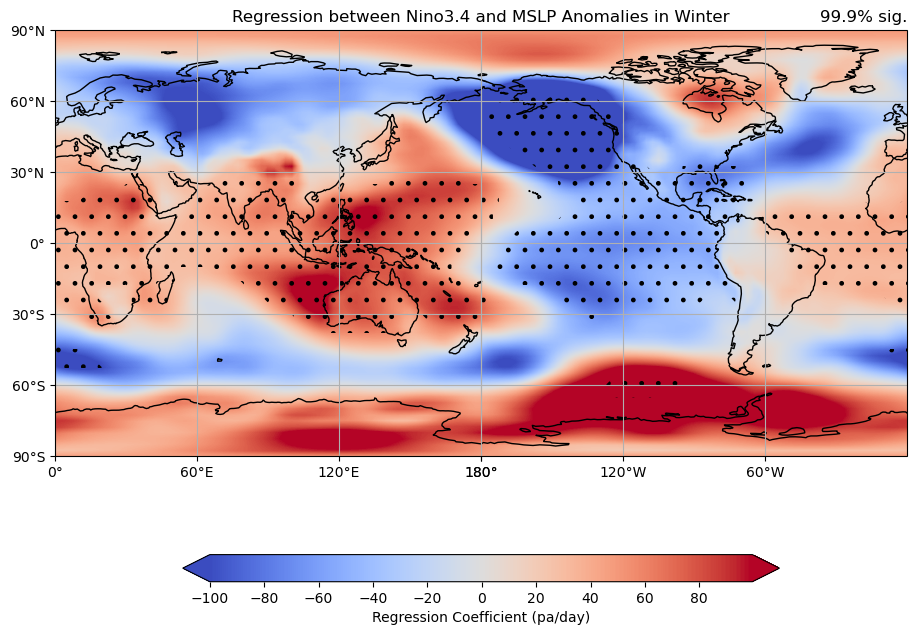

In [43]:
#plotting
clevs = np.arange(-100,100.,0.5)

fig = plt.figure(figsize = (11,8.5))

# Set the axes using the specified map projection
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = 180))

# Add cyclic point
data = m_array
data,lon = add_cyclic_point(data,coord = mslp_anom_detrended['lon'])
mask_data,lons = add_cyclic_point(mask_sig,coord = mslp_anom_detrended['lon'])

# Make a filled contour plot
cs = ax.contourf(lon,mslp_anom_detrended["lat"],
            data,clevs,
            transform = ccrs.PlateCarree(),
            cmap = 'coolwarm',extend = 'both')

ax.contourf(lon,mslp_anom_detrended['lat'],mask_data,[0,1],
            transform = ccrs.PlateCarree(),colors='None',
            hatches=['.','.'],extend='both',alpha=0)

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs=ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs=ccrs.PlateCarree())
lat_formatter=cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar=plt.colorbar(cs,orientation='horizontal',shrink=0.7,
                 label='Regression Coefficient (pa/day)')

# Add title
plt.title('Regression between Nino3.4 and MSLP Anomalies in Winter')
plt.title('99.9% sig.',loc='right')